In [1]:
import numpy as np
import torch
from torch.utils.data import Dataset
import h5py
import torch.nn.functional as F

class GalaxyDataset(Dataset):
    """PyTorch Dataset for Galaxy images with metadata from HDF5"""
    def __init__(self, hdf5_path, transform=None):
        self.transform = transform
        with h5py.File(hdf5_path, "r") as f:
            self.images = np.array(f["images"], dtype=np.float32) / 255.0
            self.labels = np.array(f["ans"], dtype=np.int64)
            self.metadata = {key: np.array(f[key]) for key in ["ra", "dec", "redshift", "pxscale"]}

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        image = torch.tensor(self.images[idx]).permute(2, 0, 1)  # HWC -> CHW
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            image = self.transform(image)
        metadata = {key: val[idx] for key, val in self.metadata.items()}
        return image, label, metadata


In [2]:
import torch
import torch.nn as nn

class GalaxyCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_p=0.5):
        super(GalaxyCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 256 -> 128
            nn.Dropout(dropout_p),
            
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128 -> 64
            nn.Dropout(dropout_p),
            
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64 -> 32
            nn.Dropout(dropout_p),
            
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16
            nn.Dropout(dropout_p),
            
            # Block 5
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # Global pooling
            nn.Dropout(dropout_p)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [3]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

test_transforms = transforms.Compose([])  # no augmentation


In [4]:
from torch.utils.data import random_split

dataset = GalaxyDataset("../data/Galaxy10_DECals.h5")  # transform applied later

test_ratio = 0.25
test_size = int(len(dataset) * test_ratio)
train_size = len(dataset) - test_size



In [5]:
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# Wrap subsets with transforms
from torch.utils.data import Dataset

class TransformedSubset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label



In [6]:
train_dataset = TransformedSubset(train_dataset, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset, transform=test_transforms)


In [7]:
len(train_dataset)

13302

In [8]:
# import torch
# from torch.utils.data import Subset
# import random
# n = len(train_dataset) # replace with whatever number you want

# # Make sure n does not exceed the original train dataset size
# n = min(n, len(train_dataset))

# # Generate random indices
# random_indices = random.sample(range(len(train_dataset)), n)

# # Create a subset with only these random indices
# train_dataset = Subset(train_dataset, random_indices)

In [9]:
from torch.utils.data import DataLoader

batch_size = 32
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=True,
)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)



cuda


In [11]:
import matplotlib.pyplot as plt

image, label = dataset[2954]


# HWC
plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("HWC (original)")
plt.axis("off")

# CHW -> HWC (for visualization)
plt.subplot(1, 2, 2)
plt.imshow(image[0])
plt.title("CHW → HWC")
plt.axis("off")


ValueError: too many values to unpack (expected 2)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Model ---
import torchvision.models as models
import torch.nn as nn

model = GalaxyCNN()

# Replace classifier

model = model.to(device)

import torch
import torch.nn as nn

# Кількість зразків у кожному класі
class_counts = torch.tensor([
    1081,  # 0 Disturbed
    1853,  # 1 Merging
    2645,  # 2 Round Smooth
    2027,  # 3 In-between
    334,   # 4 Cigar (ДУЖЕ мало)
    2043,  # 5 Barred Spiral
    1829,  # 6 Tight Spiral
    2628,  # 7 Loose Spiral
    1423,  # 8 Edge-on no bulge
    1873   # 9 Edge-on bulge
], dtype=torch.float)

weights = class_counts.sum() / class_counts
weights = weights / weights.sum()
weights = weights.to(device)

# Loss з вагами
criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.AdamW(model.parameters(), lr=0.01)  # weight decay helps generalization

# --- Optional LR Scheduler ---
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', 
                                                 factor=0.5, patience=3)

# --- Training configuration ---
num_epochs = 30


In [ ]:
import matplotlib.pyplot as plt

# Lists to store metrics
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []



for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss, correct, total = 0, 0, 0
    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss /= total
    train_acc = correct / total

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels, _ in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Save metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")



KeyboardInterrupt: 

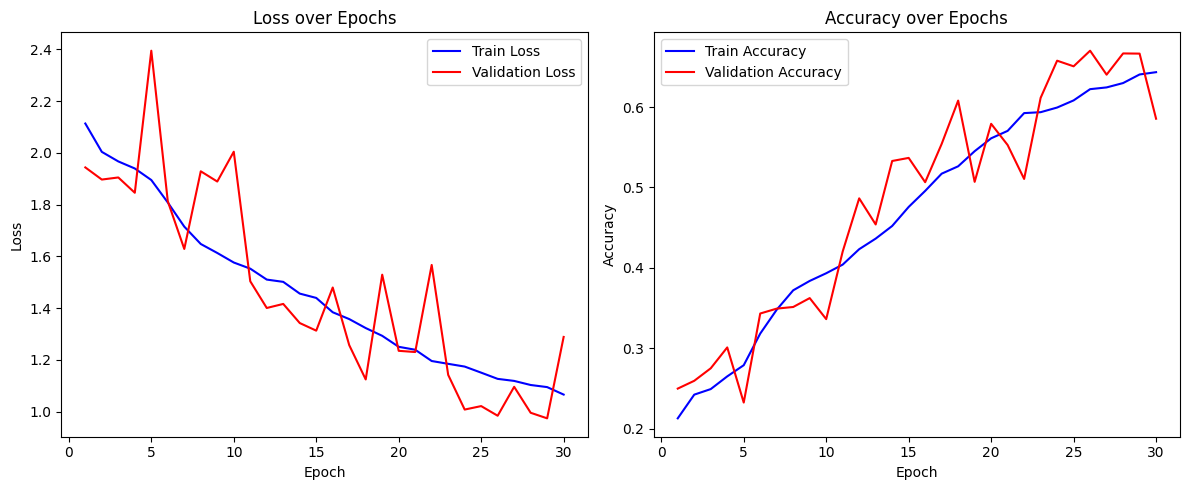

In [ ]:
epochs = range(1, epoch+2)

plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train Loss')
plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plot Accuracy
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, 'b-', label='Train Accuracy')
plt.plot(epochs, val_accuracies, 'r-', label='Validation Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 10

# Replace with your trained weights path
model.eval()

# -------------------------
# 3. Galaxy10 class names
# -------------------------
class_names = [
    "spiral", "elliptical", "lenticular", "irregular", "ring",
    "merger", "dwarf", "s0", "peculiar", "unknown"
]

# -------------------------
# 4. Preprocessing
# -------------------------
preprocess = transforms.Compose([
    # transforms.Resize((256, 256)),
    # transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
    #                      std=[0.229, 0.224, 0.225])
])

# -------------------------
# 5. Prediction function
# -------------------------
def predict_galaxy(image_path, model, class_names):
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        outputs = model(input_batch)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_idx = torch.argmax(probabilities, dim=1).item()
    
    return {
        "predicted_class": class_names[predicted_idx],
        "predicted_index": predicted_idx,
        "probabilities": probabilities.cpu().numpy()
    }

# Get image from dataset

correcttest = 0
predicted = []
true = []
for i in range(len(dataset)):
    image, label, metadata = dataset[i]  # already a torch tensor

    # Add batch dimension
    input_batch = image.unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad():
        outputs = model(input_batch)
        probs = torch.softmax(outputs, dim=1)
        pred_idx = torch.argmax(probs, dim=1).item()

    if(i % 1000 == 0):
        print("Iterating")

    if(class_names[pred_idx] == class_names[label.item()]):
        correcttest += 1

    predicted.append(class_names[pred_idx])
    true.append(class_names[label.item()])
    # print("Predicted class:", class_names[pred_idx])
    # print("True class:", class_names[label.item()])

print(correcttest/len(dataset))


Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
Iterating
0.5927492106450157


In [ ]:
import torch
from torchmetrics.classification import MulticlassConfusionMatrix

class_to_idx = {name: idx for idx, name in enumerate(class_names)}

pred_labels = torch.tensor([class_to_idx[x] for x in predicted], dtype=torch.int64)
true_labels = torch.tensor([class_to_idx[x] for x in true], dtype=torch.int64)

metric = MulticlassConfusionMatrix(num_classes=len(class_names))

# Обчислюємо матрицю конфузії
cm = metric(pred_labels, true_labels)
print(cm)


tensor([[   0,   10,  225,  155,    8,   16,  192,  391,   71,   13],
        [   0,  886,  362,  132,    1,   44,   37,  299,   56,   36],
        [   0,    4, 2594,    7,    0,    0,   34,    4,    2,    0],
        [   0,    5,  451, 1465,    0,    0,   95,    8,    2,    1],
        [   0,    0,   10,  112,   13,    0,   47,   55,   86,   11],
        [   0,   16,   58,   62,    5, 1062,  204,  593,   37,    6],
        [   0,    1,  352,   91,    1,   13,  978,  349,   43,    1],
        [   0,   13,  217,  102,    3,   71,  702, 1420,   90,   10],
        [   0,    1,    5,    2,    4,    0,    2,   22, 1366,   21],
        [   0,    5,   36,   49,    9,    2,   13,   15, 1015,  729]])


            spiral  elliptical  lenticular  irregular  ring  merger  dwarf  \
spiral           0          10         225        155     8      16    192   
elliptical       0         886         362        132     1      44     37   
lenticular       0           4        2594          7     0       0     34   
irregular        0           5         451       1465     0       0     95   
ring             0           0          10        112    13       0     47   
merger           0          16          58         62     5    1062    204   
dwarf            0           1         352         91     1      13    978   
s0               0          13         217        102     3      71    702   
peculiar         0           1           5          2     4       0      2   
unknown          0           5          36         49     9       2     13   

              s0  peculiar  unknown  
spiral       391        71       13  
elliptical   299        56       36  
lenticular     4         2 

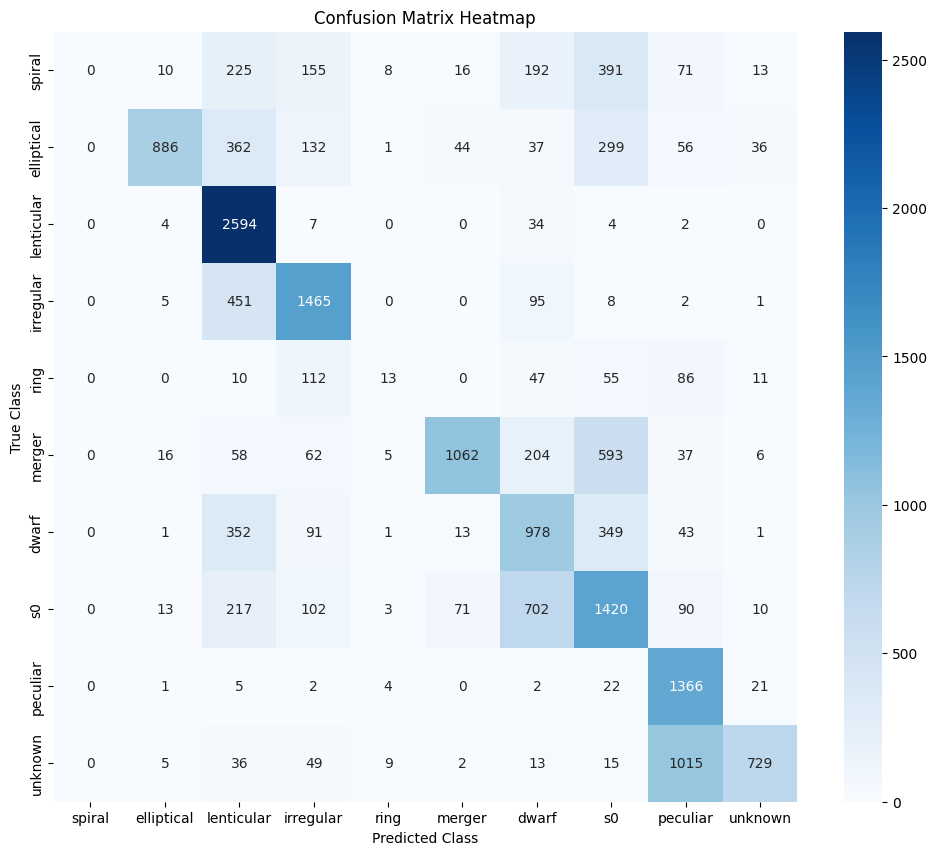

In [ ]:
import pandas as pd

class_names = [
    "spiral", "elliptical", "lenticular", "irregular", "ring",
    "merger", "dwarf", "s0", "peculiar", "unknown"
]

cm_df = pd.DataFrame(cm.numpy(), index=class_names, columns=class_names)

print(cm_df)

import seaborn as sns
plt.figure(figsize=(12,10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=True)
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [ ]:
labels[5]

tensor(0, device='cuda:0')

In [ ]:
cm_np = cm.numpy()
precision = []
recall = []
f1 = []

for i in range(len(class_names)):
    tp = cm_np[i, i]  # True Positive
    fp = cm_np[:, i].sum() - tp 
    fn = cm_np[i, :].sum() - tp 
    
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    
    precision.append(prec)
    recall.append(rec)
    f1.append(f1_score)

# Створюємо DataFrame
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
})

# Красивий друк
metrics_df = metrics_df.round(3)
print(metrics_df)

        Class  Precision  Recall  F1-score
0      spiral      0.000   0.000     0.000
1  elliptical      0.942   0.478     0.634
2  lenticular      0.602   0.981     0.746
3   irregular      0.673   0.723     0.697
4        ring      0.295   0.039     0.069
5      merger      0.879   0.520     0.653
6       dwarf      0.424   0.535     0.473
7          s0      0.450   0.540     0.491
8    peculiar      0.493   0.960     0.652
9     unknown      0.880   0.389     0.540
